## Exercício

Considere $X \sim \mathrm{Binomial}(n,p)$.

1. Implemente a simulação de $X$ pelo método ingênuo, escrevendo $X$ como soma de $n$ variáveis aleatórias independentes com distribuição $\mathrm{Bernoulli}(p)$.

2. Implemente o método recursivo visto em sala:

   * Gere $U \sim U(0,1)$.

   * Inicialize $i=0$, $p_i=(1-p)^n$ e $F=p_i$.

   * Enquanto $U>F$, faça

     $$
     p_{i+1}=
     \frac{n-i}{i+1}
     \frac{p}{1-p}
     p_i,
     $$

     e atualize $i \leftarrow i+1$ e $F \leftarrow F+p_i$.

   * Retorne $X=i$.

3. Use a função `np.linspace` para reproduzir os passos anteriores para diferentes valores de $p$ e $n$, compare o tempo de execução dos dois métodos. Para cada valor de $p$ e $n$, execute cada método 100 vezes e calcule a média dos tempos. Utilize `time.time()` para medir o tempo de execução de cada método.

4. Apresente os resultados em uma tabela ou gráfico e comente como o tempo de execução dos métodos varia com $p$.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
#Criando a binomial ingenua
b = 0
p = .5
N = 100
for i in range(N):
  u = np.random.uniform()
  if u > p:
    b += 1
print(b)


53


In [5]:
#Criando a binomial recursiva
u = np.random.uniform()
i = 0
p = .5
N = 100
pi = (1-p)**N
F = pi
while u > F:
    pi = ((N-i)/(i+1)) * (p/(1-p))* pi
    i += 1
    F += pi

print(i)

50


In [31]:
import time
from tqdm import tqdm
p_valores = np.linspace(0.01, 0.99, 10)
tempo_ingenuo = []
tempo_recursivo = []

for p in p_valores:
  tempo_rec = []
  tempo_ing = []
  for i in tqdm(range(100)):
    inicio = time.time()
    n = 100
    N = 1000
    amostra_ing = []
    for j in range(N):
      u = np.random.uniform(size=N)
      binomial = np.sum(u<p)
      amostra_ing.append(binomial)
    fim = time.time()
    tempo = fim-inicio
    tempo_ing.append(tempo)
    inicio_rec = time.time()
    amostra_recursiva = []
    for k in range(N):
      i = 0
      pi = (1-p)**n
      F = pi
      U = np.random.uniform()
      while U > F:
        pi = ((n-i)/(i+1))*(p/(1-p))*pi
        i += 1
        F += pi
    fim_rec = time.time()
    tempoo = fim_rec - inicio_rec
    tempo_rec.append(tempoo)
  tempo_ingenuo.append(np.mean(tempo_ing))
  tempo_recursivo.append(np.mean(tempo_rec))




100%|██████████| 100/100 [00:11<00:00,  8.53it/s]


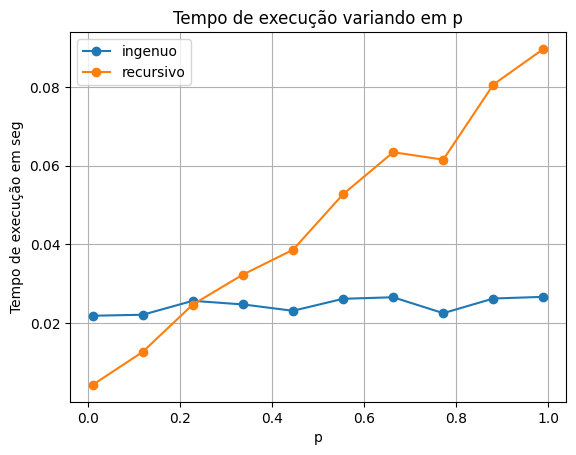

In [34]:
plt.plot(p_valores, tempo_ingenuo, marker='o', label='ingenuo')
plt.plot(p_valores, tempo_recursivo, marker='o', label='recursivo')
plt.xlabel('p')
plt.ylabel('Tempo de execução em seg')
plt.title('Tempo de execução variando em p')
plt.legend()
plt.grid(True)
plt.show()

Reparamos que conforme o p aumenta, o tempo do metodo recursivo aumenta, diferente do metodo recursivo que se mantem constante independende do valor de p